# Fig1-Fig8 plotting directly from Source_Data file

In [ ]:

import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.ndimage.filters import convolve1d

###plotting params ###
PYR_COLOR = "tab:red"
IN_COLOR = "royalblue"
PYR_COLOR_weak='indianred'
IN_COLOR_weak='cornflowerblue'
SVG_TICKS = 6
SVG_LABELS = 7

from analysis_funcs_and_consts import smooth

sns.set_style("white")
plt.rcParams["font.family"] = "Arial"

SOURCE_DATA_DIR = r"your_path...."
MERGED_PATH = SOURCE_DATA_DIR + r"\Source_Data.xlsx"

CKII_COLOR = PYR_COLOR
SST_COLOR = IN_COLOR
STRAIN_COLORS = {"CKII": CKII_COLOR, "SST": SST_COLOR}

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = convolve1d(y, box)
    return y_smooth


def parse_vector(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return np.asarray(v, dtype=float)
    if pd.isna(v):
        return np.array([], dtype=float)

    s = str(v).strip().replace("\n", " ").replace("\r", " ")
    if s == "":
        return np.array([], dtype=float)

    if s.startswith("[") and s.endswith("]"):
        inner = s[1:-1].strip()
    else:
        inner = s

    sep = "," if "," in inner else " "
    arr = np.fromstring(inner, sep=sep)
    if arr.size > 0:
        return arr

    try:
        parsed = ast.literal_eval(s)
        return np.asarray(parsed, dtype=float).ravel()
    except Exception:
        return np.array([], dtype=float)


def stack_vectors(series, min_len=None):
    vecs = [parse_vector(v) for v in series]
    vecs = [v for v in vecs if v.size > 0]
    if not vecs:
        return np.empty((0, 0))
    n = min_len if min_len is not None else min(v.size for v in vecs)
    return np.vstack([v[:n] for v in vecs])


def mean_sem(mat):
    if mat.size == 0:
        return np.array([]), np.array([])
    mean = np.nanmean(mat, axis=0)
    sem = stats.sem(mat, axis=0, nan_policy="omit")
    return mean, sem


def violin_by_strain(df, value_col, title="", ylabel="", ylim=None):
    fig, ax = plt.subplots(figsize=(3, 3))
    order = [s for s in ["CKII", "SST"] if s in df["Strain"].unique()]
    sns.violinplot(data=df, x="Strain", y=value_col, order=order, palette=STRAIN_COLORS, inner=None, cut=0, ax=ax)
    sns.stripplot(data=df, x="Strain", y=value_col, order=order, palette=STRAIN_COLORS, size=2, alpha=0.35, jitter=0.2, ax=ax)
    ax.set_ylabel(ylabel if ylabel else value_col)
    ax.set_xlabel("")
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


xls = pd.ExcelFile(MERGED_PATH)
SHEETS = {name: pd.read_excel(MERGED_PATH, sheet_name=name) for name in xls.sheet_names}
print(f"Loaded {len(SHEETS)} sheets from {Path(MERGED_PATH).name}")


def get_df(sheet_or_file_name):
    if sheet_or_file_name in SHEETS:
        return SHEETS[sheet_or_file_name].copy()
    fallback = SOURCE_DATA_DIR + rf"\{sheet_or_file_name}.xlsx"
    return pd.read_excel(fallback)

print(sorted(SHEETS.keys()))


def mm_to_inches(figsize_mm):
    return tuple(v / 25.4 for v in figsize_mm)


def normalize_safe(vec):
    vec = np.asarray(vec, dtype=float)
    finite = np.isfinite(vec)
    if not finite.any():
        return np.zeros_like(vec, dtype=float)
    mn = np.nanmin(vec)
    mx = np.nanmax(vec)
    if mx == mn:
        return np.where(finite, 0, np.nan).astype(float)
    return (vec - mn) / (mx - mn)


def normalize_rows(mat):
    mat = np.asarray(mat, dtype=float)
    if mat.ndim == 1:
        mat = mat.reshape(1, -1)
    return np.vstack([normalize_safe(row) for row in mat]) if len(mat) else mat


def sort_rows_by_max_index(mat):
    mat = np.asarray(mat, dtype=float)
    if mat.size == 0:
        return mat, np.array([], dtype=int)
    score = np.where(np.isfinite(mat), mat, -np.inf)
    idx = np.argsort(np.argmax(score, axis=1))
    return mat[idx], idx


def strip_top_right(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def p_to_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def paper_violin(data_dict, colors, figsize_mm=(12.5, 25), width=0.5, ylim=None,
                 linewidth=0.5, jitter=0.02, scatter_size=2, alpha=0.3,
                 edgecolor='gray', inner_linewidth=0.5, yticks=None, ylabel=None,
                 significance_pairs=None, significance_labels=None, tick_fontsize=SVG_TICKS,
                 label_fontsize=SVG_LABELS, xticklabels=None, rotation=0):
    fig, ax = plt.subplots(figsize=mm_to_inches(figsize_mm))
    labels = list(data_dict.keys())
    data = [np.asarray(data_dict[label], dtype=float) for label in labels]
    data = [d[np.isfinite(d)] for d in data]
    sns.violinplot(data=data, color='white', linewidth=linewidth, width=width,
                   zorder=0, alpha=1, inner=None, ax=ax)
    for collection in ax.collections:
        collection.set_edgecolor(edgecolor)
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(inner_linewidth)
    for i, vals in enumerate(data):
        ax.scatter(np.random.normal(i, jitter, size=len(vals)), vals, color=colors[i],
                   s=scatter_size, alpha=alpha, edgecolors='none')
        if len(vals):
            ax.scatter(i, np.nanmean(vals), color='k', s=scatter_size * 2, zorder=2, edgecolors='none')
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontsize=tick_fontsize)
    else:
        ax.tick_params(axis='y', labelsize=tick_fontsize)
    if xticklabels is None:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(len(xticklabels)), xticklabels, fontsize=label_fontsize, rotation=rotation)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
    if ylim is not None:
        ax.set_ylim(ylim)
    elif any(len(v) for v in data):
        ymax = max(np.nanmax(v) for v in data if len(v))
        ymin = min(np.nanmin(v) for v in data if len(v))
        ax.set_ylim([0 if ymin >= 0 else ymin * 1.2, ymax * 1.2])
    if significance_pairs:
        y_low, y_high = ax.get_ylim()
        yrange = y_high - y_low
        for k, (x1, x2) in enumerate(significance_pairs):
            if len(data[x1]) == 0 or len(data[x2]) == 0:
                continue
            label = significance_labels[k] if significance_labels and k < len(significance_labels) else p_to_stars(stats.ranksums(data[x1], data[x2]).pvalue)
            y = max(np.nanmax(data[x1]), np.nanmax(data[x2])) + yrange * (0.075 + 0.08 * k)
            ax.plot([x1, x1, x2, x2], [y, y, y, y], lw=0.5, c='k')
            ax.text((x1 + x2) / 2, y + yrange * 0.01, label, ha='center', va='bottom', color='k', fontsize=tick_fontsize)
    strip_top_right(ax)
    fig.patch.set_facecolor('none')
    ax.yaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.5)
    plt.show()
    return fig, ax


Loaded 42 sheets from merged_sheets_corrected.xlsx
['1b_bottom', '1b_top', '1e', '1f', '1g', '1h', '1i', '1j', '2c_d', '2e', '2f', '2g', '2h', '2i', '3b', '3c', '3d', '3e', '4e', '4f', '4g', '5b', '5d', '5e', '5f', '6b', '6c', '6d', '6e', '6f', '7b', '7d', '7e_tuned', '7e_untuned', '7f', '7g', '7h_control', '7h_remap', '8a-d', '8e', '8f', '8g']


## Fig1

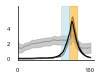

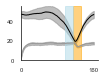

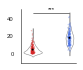

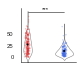

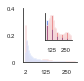

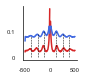

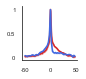

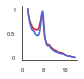

In [2]:
# Fig 1b: original 35 x 25 mm line format with reward and anticipation zones
CM_CONVERT = 160 / 190
START_REWARD, END_REWARD = 128 * CM_CONVERT, 148 * CM_CONVERT
X_LIM = (0, 160)
ANTICIPATION = END_REWARD - START_REWARD


def plot_1b(sheet_name, y_col, sem_col, y_lim, y_ticks, y_ticklabels, linewidth=1):
    plot_df = SHEETS[sheet_name]
    plt.figure(figsize=mm_to_inches((35, 25)))
    for condition, color in [('before training', '0.6'), ('after training', 'k')]:
        df = plot_df[plot_df['condition'] == condition].sort_values('end_of_bin')
        plt.plot(df['end_of_bin'], df[y_col], color=color, linewidth=linewidth, label=condition)
        plt.fill_between(df['end_of_bin'], df[y_col] - df[sem_col], df[y_col] + df[sem_col],
                         color=color if y_col == 'lick_rate_mean' else 'grey', alpha=0.5, label='_nolegend_')
    plt.axvspan(START_REWARD, END_REWARD, alpha=0.5, color='orange')
    plt.axvspan(START_REWARD - ANTICIPATION, START_REWARD - 0.2, alpha=0.5, color='lightblue')
    plt.xlim(*X_LIM)
    plt.ylim(*y_lim)
    plt.xticks([0, 150], [0, 160], fontsize=6)
    plt.yticks(y_ticks, y_ticklabels, fontsize=6)
    ax = plt.gca()
    strip_top_right(ax)
    ax.set_facecolor('none')
    plt.show()

plot_1b('1b_top', 'lick_rate_mean', 'lick_rate_sem', (-0.2, 7), [0, 2, 4], [0, 2, 4])
plot_1b('1b_bottom', 'speed_mean', 'speed_sem', (0, 550), [0, 200, 400], [0, 20, 40])

# Fig 1e and 1f
for sheet, col, yticks, jitter in [('1e', 'Mean_FR', [0, 20, 40], 0.02), ('1f', '% ISI < 10 ms', [0, 25, 50], 0.03)]:
    data = {
        'CKII': SHEETS[sheet].loc[SHEETS[sheet]['Strain'] == 'CKII', col].dropna().to_numpy(),
        'SST': SHEETS[sheet].loc[SHEETS[sheet]['Strain'] == 'SST', col].dropna().to_numpy(),
    }
    paper_violin(data, [PYR_COLOR, IN_COLOR], figsize_mm=(25, 25), jitter=jitter,
                 yticks=yticks, ylim=(-10, max(map(np.nanmax, data.values())) * 1.2),
                 significance_pairs=[(0, 1)], significance_labels=['***'])

# Fig 1g
CKII_ISIs, SST_ISIs = [], []
for strain, target in [('CKII', CKII_ISIs), ('SST', SST_ISIs)]:
    for s in SHEETS['1g'].loc[SHEETS['1g']['Strain'] == strain, 'list of ISIs (ms)']:
        target.extend(parse_vector(s).tolist())
CKII_ISIs = [x for x in CKII_ISIs if x < 300]
SST_ISIs = [x for x in SST_ISIs if x < 300]
CKII_ISI2 = [x for x in CKII_ISIs if (x > 80) and (x < 300)]
SST_ISI2 = [x for x in SST_ISIs if (x > 80) and (x < 300)]
fig, ax = plt.subplots(figsize=mm_to_inches((25, 25)))
plt.hist(CKII_ISIs, bins=50, alpha=0.5, weights=np.ones(len(CKII_ISIs)) / len(CKII_ISIs), color=PYR_COLOR)
plt.hist(SST_ISIs, bins=50, alpha=0.5, weights=np.ones(len(SST_ISIs)) / len(SST_ISIs), color=IN_COLOR)
plt.xticks([2, 125, 250], [2, 125, 250], fontsize=SVG_TICKS)
plt.yticks([0, 0.2, 0.4], [0, 0.2, 0.4], fontsize=SVG_TICKS)
strip_top_right(plt.gca())
ax_inset = inset_axes(plt.gca(), width='50%', height='50%', loc='upper right')
ax_inset.hist(SST_ISI2, bins=20, alpha=0.7, weights=np.ones(len(SST_ISI2)) / len(SST_ISIs), color=IN_COLOR)
ax_inset.hist(CKII_ISI2, bins=20, alpha=0.5, weights=np.ones(len(CKII_ISI2)) / len(CKII_ISIs), color=PYR_COLOR)
ax_inset.set_xticks([125, 250])
ax_inset.yaxis.set_visible(False)
strip_top_right(ax_inset)
ax_inset.tick_params(axis='both', which='major', labelsize=6)
plt.show()

# Fig 1h
CKII_mat = stack_vectors(SHEETS['1h'].loc[SHEETS['1h']['Strain'] == 'CKII', 'Autocorrelogram values'])
SST_mat = stack_vectors(SHEETS['1h'].loc[SHEETS['1h']['Strain'] == 'SST', 'Autocorrelogram values'])
mean_ckii = np.nanmean(CKII_mat, axis=0)
mean_sst = np.nanmean(SST_mat, axis=0)
center = len(mean_ckii) // 2
if len(mean_ckii) > center + 1:
    mean_ckii[center - 1] = np.nan; mean_ckii[center + 1] = np.nan
    mean_sst[center - 1] = np.nan; mean_sst[center + 1] = np.nan
plt.figure(figsize=mm_to_inches((25, 25)))
plt.plot(mean_ckii, color=PYR_COLOR, linewidth=1.5)
plt.plot(mean_sst, color=IN_COLOR, linewidth=1.5)
max_lag, bin_size = 500, 4
line_x = max_lag // bin_size
plt.xticks([0, line_x, line_x * 2], [str(-max_lag), 0, str(max_lag)], fontsize=SVG_TICKS)
plt.yticks([0, 0.1], [0, 0.1], fontsize=SVG_TICKS)
for xpos in [line_x / 2, line_x + line_x / 2, line_x / 2 + line_x / 4, line_x + line_x / 4, line_x + line_x * 3 / 4, line_x / 2 - line_x / 4]:
    idx = int(round(xpos))
    if 0 <= idx < len(mean_sst):
        plt.plot([xpos, xpos], [0, mean_sst[idx]], color='k', linewidth=0.5, linestyle='--')
strip_top_right(plt.gca())
plt.show()

# Fig 1i
CKII_shape = stack_vectors(SHEETS['1i'].loc[SHEETS['1i']['Strain'] == 'CKII', 'Spike shape values'])
SST_shape = stack_vectors(SHEETS['1i'].loc[SHEETS['1i']['Strain'] == 'SST', 'Spike shape values'])
fig, ax = plt.subplots(figsize=mm_to_inches((25, 25)))
mean_ckii = normalize_safe(np.nanmean(CKII_shape, axis=0)); mean_sst = normalize_safe(np.nanmean(SST_shape, axis=0))
sem_ckii = stats.sem(CKII_shape, axis=0, nan_policy='omit'); sem_sst = stats.sem(SST_shape, axis=0, nan_policy='omit')
plt.plot(mean_ckii, color=PYR_COLOR, linewidth=1.5); plt.plot(mean_sst, color=IN_COLOR, linewidth=1.5)
plt.fill_between(range(len(mean_ckii)), mean_ckii - sem_ckii, mean_ckii + sem_ckii, color=PYR_COLOR, alpha=0.3)
plt.fill_between(range(len(mean_sst)), mean_sst - sem_sst, mean_sst + sem_sst, color=IN_COLOR, alpha=0.3)
plt.yticks([0, 0.5, 1], [0, 0.5, 1], fontsize=SVG_TICKS); plt.xticks([0, 25, 50], ['-50', '0', '50'], fontsize=SVG_TICKS)
strip_top_right(plt.gca()); plt.show()

# Fig 1j
CKII_PSDs = stack_vectors(SHEETS['1j'].loc[SHEETS['1j']['Strain'] == 'CKII', 'Power Spectrum values'])
SST_PSDs = stack_vectors(SHEETS['1j'].loc[SHEETS['1j']['Strain'] == 'SST', 'Power Spectrum values'])
freqs = np.arange(2, 20, 0.1)[:CKII_PSDs.shape[1]]
fig, ax = plt.subplots(figsize=mm_to_inches((25, 25)))
plt.plot(freqs, normalize_safe(np.nanmean(CKII_PSDs, axis=0)), color=PYR_COLOR, linewidth=1.5)
plt.plot(freqs, normalize_safe(np.nanmean(SST_PSDs, axis=0)), color=IN_COLOR, linewidth=1.5)
plt.yticks([0, 0.5, 1], [0, 0.5, 1], fontsize=SVG_TICKS)
plt.xticks([0, 8, 16], [0, 8, 16], fontsize=SVG_TICKS)
strip_top_right(plt.gca())
plt.show()

## Fig2

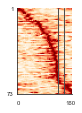

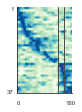

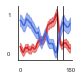

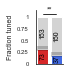

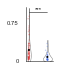

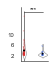

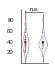

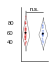

In [ ]:
# Fig 2c/2d: heatmaps and population curves with original sorting/ticks
f2 = SHEETS['2c_d']
matrices = {}
for strain in ['CKII', 'SST']:
    raw = stack_vectors(f2.loc[f2['Strain'] == strain, 'FR_vec'], min_len=48)
    normed = normalize_rows(raw)
    sorted_norm, sorted_idx = sort_rows_by_max_index(normed)
    matrices[strain] = {'raw': raw, 'normed': normed, 'sorted_norm': sorted_norm, 'sorted_idx': sorted_idx}

for strain, cmap in [('CKII', 'OrRd'), ('SST', 'GnBu')]:
    matrix = matrices[strain]['sorted_norm']
    plt.figure(figsize=mm_to_inches((25, 40)))
    plt.imshow(matrix, aspect='auto', cmap=cmap)
    plt.yticks([0, len(matrix) - 1], [1, len(matrix)], fontsize=SVG_TICKS)
    plt.xticks([0, 46], [0, 160], fontsize=SVG_TICKS)
    ax = plt.gca(); strip_top_right(ax)
    plt.axvline(35, color='0.3', linewidth=1); plt.axvline(40, color='0.3', linewidth=1)
    ax.tick_params(axis='y', width=0, pad=0)
    plt.show()

fig, ax = plt.subplots(figsize=mm_to_inches((25, 25)))
ckii = matrices['CKII']['sorted_norm']; sst = matrices['SST']['sorted_norm']
ckii_mean = np.nanmean(ckii, axis=0); sst_mean = np.nanmean(sst, axis=0)
min_val = np.nanmin([np.nanmin(ckii_mean), np.nanmin(sst_mean)])
max_val = np.nanmax([np.nanmax(ckii_mean), np.nanmax(sst_mean)])
plt.plot(ckii_mean, color=PYR_COLOR, linewidth=1.5); plt.plot(sst_mean, color=IN_COLOR, linewidth=1.5)
plt.fill_between(np.arange(48), ckii_mean - stats.sem(ckii, axis=0, nan_policy='omit'), ckii_mean + stats.sem(ckii, axis=0, nan_policy='omit'), alpha=0.5, color=PYR_COLOR)
plt.fill_between(np.arange(48), sst_mean - stats.sem(sst, axis=0, nan_policy='omit'), sst_mean + stats.sem(sst, axis=0, nan_policy='omit'), alpha=0.5, color=IN_COLOR)
plt.xticks([0, 47], ['0', '160'], fontsize=SVG_TICKS); plt.yticks([min_val, max_val], [0, 1], fontsize=SVG_TICKS)
plt.axvline(x=35, color='k', alpha=0.7, linewidth=1); plt.axvline(x=40, color='k', alpha=0.7, linewidth=1)
strip_top_right(plt.gca()); plt.show()

# Fig 2e: stacked tuned/untuned bars 
f2e = SHEETS['2e']
counts = {}
for strain in ['CKII', 'SST']:
    d = f2e[f2e['Strain'] == strain]
    tuned = int(d['is_tuned'].astype(bool).sum())
    total = int(len(d))
    counts[strain] = {'tuned': tuned, 'untuned': total - tuned, 'total': total}
prop_tuned_CKII = counts['CKII']['tuned'] / counts['CKII']['total']; prop_tuned_SST = counts['SST']['tuned'] / counts['SST']['total']
prop_untuned_CKII = 1 - prop_tuned_CKII; prop_untuned_SST = 1 - prop_tuned_SST
CKII_CI_low, CKII_CI_high = proportion_confint(counts['CKII']['tuned'], counts['CKII']['total'], method='wilson')
SST_CI_low, SST_CI_high = proportion_confint(counts['SST']['tuned'], counts['SST']['total'], method='wilson')
fig, ax = plt.subplots(figsize=mm_to_inches((12.5, 25)))
x = np.arange(2); bar_width = 0.8
tuned_props = [prop_tuned_CKII, prop_tuned_SST]; untuned_props = [prop_untuned_CKII, prop_untuned_SST]
tuned_counts = [counts['CKII']['tuned'], counts['SST']['tuned']]; untuned_counts = [counts['CKII']['untuned'], counts['SST']['untuned']]
plt.bar(x, tuned_props, width=bar_width, color=[PYR_COLOR, IN_COLOR], zorder=2)
plt.bar(x, untuned_props, width=bar_width, bottom=tuned_props, color='lightgray', zorder=1)
for i, (lo, hi) in enumerate([(CKII_CI_low, CKII_CI_high), (SST_CI_low, SST_CI_high)]):
    plt.fill_between([x[i] - bar_width / 2, x[i] + bar_width / 2], [lo, lo], [hi, hi], color='k', alpha=0.2, linewidth=0, zorder=3)
for i in range(2):
    plt.text(x[i], tuned_props[i] / 2, f'{tuned_counts[i]}', ha='center', va='center', rotation=90, color='k', fontsize=SVG_LABELS)
    plt.text(x[i], tuned_props[i] + untuned_props[i] / 2, f'{untuned_counts[i]}', ha='center', va='center', rotation=90, color='k', fontsize=SVG_LABELS)
plt.yticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize=SVG_TICKS); plt.xticks([])
strip_top_right(ax); plt.ylabel('Fraction tuned', fontsize=SVG_LABELS)
_, p_value = proportions_ztest(np.array([counts['CKII']['tuned'], counts['SST']['tuned']]), np.array([counts['CKII']['total'], counts['SST']['total']]))
plt.plot([0, 0, 1, 1], [1.08, 1.08, 1.08, 1.08], lw=0.8, c='k')
plt.text(0.5, 1.09, p_to_stars(p_value).replace('.', ''), ha='center', va='bottom', fontsize=SVG_LABELS)
ax.set_ylim(0, 1.15); plt.show()

# Fig 2f-2i: original small violin format
panel_defs = [
    ('2f', 'BAE_corrected_SI', [0, 0.75, 1.5], None, ['***']),
    ('2g', 'In_out_FR_ratio', [2, 6, 10], None, None),
    ('2h', 'Place_field_width_cm', [20, 40, 60, 80], [0, 100], None),
    ('2i', 'Place_field_reliability_percent', [40, 60, 80], None, None),
]
for sheet, col, yticks, ylim, sig in panel_defs:
    d = SHEETS[sheet]
    data = {'CKII': d.loc[d['Strain'] == 'CKII', col].dropna().to_numpy(), 'SST': d.loc[d['Strain'] == 'SST', col].dropna().to_numpy()}
    paper_violin(data, [PYR_COLOR, IN_COLOR], figsize_mm=(12.5, 25), yticks=yticks, ylim=ylim,
                 significance_pairs=[(0, 1)], significance_labels=sig)

## Fig3

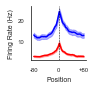

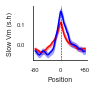

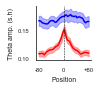

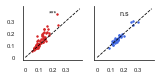

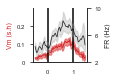

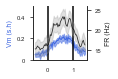

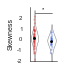

(<Figure size 35.4331x70.8661 with 1 Axes>, <Axes: ylabel='Skewness'>)

In [2]:
# Fig 3b
f3b = SHEETS['3b']

def plot_mean_with_sem_source(col, ylabel):
    vecs1 = stack_vectors(f3b.loc[f3b['Strain'] == 'CKII', col], min_len=48)
    vecs2 = stack_vectors(f3b.loc[f3b['Strain'] == 'SST', col], min_len=48)
    plt.figure(figsize=mm_to_inches((25, 25)))
    mean1, sem1 = np.mean(vecs1, axis=0), stats.sem(vecs1, axis=0)
    mean2, sem2 = np.mean(vecs2, axis=0), stats.sem(vecs2, axis=0)
    x = np.arange(len(vecs1[0]))
    plt.plot(mean1, color='r'); plt.fill_between(x, mean1 - sem1, mean1 + sem1, color='r', alpha=0.3)
    plt.plot(mean2, color='b'); plt.fill_between(x, mean2 - sem2, mean2 + sem2, color='b', alpha=0.3)
    plt.axvline(len(vecs1[0]) // 2, color='k', linestyle='dashed', linewidth=0.5)
    plt.xlabel('Position', fontsize=SVG_LABELS); plt.ylabel(ylabel, fontsize=SVG_LABELS)
    plt.xticks([0, 47 / 2, 47], ['-80', '0', '+80'], fontsize=SVG_TICKS); plt.yticks(fontsize=SVG_TICKS)
    strip_top_right(plt.gca()); plt.show()

plot_mean_with_sem_source('Centered_FR_vec', 'Firing Rate (Hz)')
plot_mean_with_sem_source('Centered_slow_Vm_vec', 'Slow Vm (s.h)')
plot_mean_with_sem_source('Centered_theta_vec', 'Theta amp. (s.h)')

# Fig 3c: in-field vs out-field theta scatter 
f3c = SHEETS['3c']
fig, axs = plt.subplots(1, 2, figsize=mm_to_inches((60, 25)))
for ax, strain, color, star in [(axs[0], 'CKII', PYR_COLOR, '***'), (axs[1], 'SST', IN_COLOR, 'n.s')]:
    d = f3c[f3c['Strain'] == strain]
    ax.scatter(d['Out_field_theta_power'], d['In_field_theta_power'], color=color, marker='o', s=2)
    ax.plot([0, 0.4], [0, 0.4], color='k', linestyle='--', linewidth=0.8)
    ax.text(0.2, 0.35, star, fontsize=SVG_LABELS, horizontalalignment='center')
yticks = [0, 0.1, 0.2, 0.3]
axs[0].set_yticks(yticks, yticks, fontsize=SVG_TICKS); axs[0].set_xticks(yticks, yticks, fontsize=SVG_TICKS)
axs[1].set_yticks([]); axs[1].set_xticks(yticks, yticks, fontsize=SVG_TICKS)
for ax in axs.flat: strip_top_right(ax)
plt.show()

# Fig 3d: average Vm shape with FR overlay
f3d = SHEETS['3d']; new_bins_num = 60
for strain, color, vm_ylim, vm_ticks, fr_ticks in [('CKII', PYR_COLOR, (0, 0.3), [0, 0.1, 0.2], [2, 6, 10]), ('SST', IN_COLOR, (0, 0.5), [0, 0.2, 0.4], [15, 20, 25])]:
    d = f3d[f3d['Strain'] == strain]
    vm_shapes = stack_vectors(d['Avg_Vm_shape'], min_len=new_bins_num)
    fr_shapes = stack_vectors(d['Avg_FR_shape'], min_len=new_bins_num)
    plt.figure(figsize=mm_to_inches((25, 25)))
    vm_mean = np.nanmean(vm_shapes, axis=0); vm_sem = stats.sem(vm_shapes, axis=0, nan_policy='omit')
    fr_mean = np.nanmean(fr_shapes, axis=0); fr_sem = stats.sem(fr_shapes, axis=0, nan_policy='omit')
    plt.plot(vm_mean, color=color, linewidth=1)
    plt.fill_between(np.arange(new_bins_num), vm_mean - vm_sem, vm_mean + vm_sem, color=color, alpha=0.5)
    plt.fill_between(np.arange(new_bins_num), fr_mean - fr_sem, fr_mean + fr_sem, color='0.6', alpha=0.5)
    plt.axvline(int(new_bins_num / 4), color='k'); plt.axvline(int(new_bins_num / 4) * 3, color='k')
    plt.ylabel('Vm (s.h)', fontsize=SVG_LABELS, color=color); plt.ylim(*vm_ylim)
    plt.xticks([int(new_bins_num / 4), int(new_bins_num / 4) * 3], ['0', '1'], fontsize=SVG_TICKS)
    plt.yticks(vm_ticks, [str(v) for v in vm_ticks], fontsize=SVG_TICKS)
    ax = plt.gca(); ax.spines['top'].set_visible(False)
    plt.twinx()
    fr_smooth = smooth(fr_mean, 3); fr_sem_smooth = smooth(fr_sem, 3)
    plt.plot(fr_smooth, color='k', linewidth=0.8, alpha=0.8)
    plt.fill_between(np.arange(new_bins_num), fr_smooth - fr_sem_smooth, fr_smooth + fr_sem_smooth, color='0.6', alpha=0.3)
    plt.ylabel('FR (Hz)', fontsize=SVG_LABELS); plt.yticks(fr_ticks, [str(v) for v in fr_ticks], fontsize=SVG_TICKS)
    plt.gca().spines['top'].set_visible(False); plt.show()

# Fig 3e
f3e = SHEETS['3e']
data_3e = {'CKII': f3e.loc[f3e['Strain'] == 'CKII', 'Vm_skewness'].dropna().to_numpy(), 'SST': f3e.loc[f3e['Strain'] == 'SST', 'Vm_skewness'].dropna().to_numpy()}
paper_violin(data_3e, [PYR_COLOR, IN_COLOR], figsize_mm=(12.5, 25), ylim=(-2, 3), scatter_size=4,
             yticks=[-2, -1, 0, 1, 2], ylabel='Skewness', significance_pairs=[(0, 1)])

## Fig4

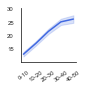

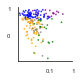

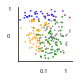

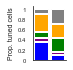

In [ ]:
# Fig 4e: SST FR by speed bin
f4e = SHEETS['4e']
speed_cols = [c for c in f4e.columns if c.startswith('Speed_Bin_')]
mat = f4e[speed_cols].to_numpy(dtype=float)
mean_speed, sem_speed = mean_sem(mat)
plt.figure(figsize=mm_to_inches((25, 25)))
plt.plot(mean_speed, label='SST', color=IN_COLOR)
plt.fill_between(range(len(mean_speed)), mean_speed - sem_speed, mean_speed + sem_speed, alpha=0.2, color=IN_COLOR)
plt.xticks([0, 1, 2, 3, 4], ['0-10', '10-20', '20-30', '30-40', '40-50'], rotation=35, fontsize=SVG_TICKS)
plt.yticks([15, 20, 25, 30], [15, 20, 25, 30], fontsize=SVG_TICKS)
plt.ylim(10, 30)
strip_top_right(plt.gca())
plt.show()

# Fig 4f: log SI vs speed-r scatter, split into SST and CKII 
classification_colors = {'Space tuned': 'g', 'Speed tuned': 'b', 'Both': 'purple', 'Both tuned': 'purple', 'Uniform': 'orange', 'Untuned': 'gray'}
for strain in ['SST', 'CKII']:
    plt.figure(figsize=mm_to_inches((25, 25)))
    plotted_labels = set()
    d = SHEETS['4f'][SHEETS['4f']['Strain'] == strain]
    for _, row in d.iterrows():
        label = row['Cell_Classification']
        color = classification_colors.get(label, 'gray')
        legend_label = label if label not in plotted_labels else None
        plt.scatter(row['SI_bits_per_spike'], row['Speed_r'], color=color, label=legend_label,
                    edgecolors='none', linewidths=0, s=3, alpha=0.8, marker='o', zorder=2)
        plotted_labels.add(label)
    plt.xscale('log')
    strip_top_right(plt.gca())
    plt.yticks(fontsize=SVG_TICKS)
    plt.xticks([0.1, 1], ['0.1', '1'], fontsize=SVG_TICKS)
    plt.tick_params(axis='x', which='minor', bottom=False, top=False, labelbottom=True)
    plt.show()

# Fig 4g: stacked classification proportions with gaps
f4g = SHEETS['4g'].copy()
label_map = {'Space tuned': 'Space', 'Both tuned': 'Both', 'Both': 'Both', 'Speed tuned': 'Speed', 'Uniform': 'Uniform', 'Untuned': 'Untuned'}
f4g['Class'] = f4g['Cell_Classification'].map(label_map).fillna(f4g['Cell_Classification'])
strains = ['SST', 'CKII']; order = ['Speed', 'Both', 'Space', 'Uniform', 'Untuned']; colors = ['blue', 'purple', 'green', 'orange', 'gray']
props = []
for cls in order:
    vals = []
    for strain in strains:
        ds = f4g[f4g['Strain'] == strain]
        vals.append((ds['Class'] == cls).sum() / len(ds))
    props.append(vals)
proportions = np.array(props)
gap = 0.02; total_gap = gap * (len(order) - 1)
proportions_adjusted = proportions - total_gap / len(order)
bottoms = np.zeros_like(proportions_adjusted)
for i in range(1, len(order)):
    bottoms[i] = bottoms[i - 1] + proportions_adjusted[i - 1] + gap
plt.figure(figsize=mm_to_inches((15, 25)))
for i, color in enumerate(colors):
    plt.bar([0, 1], proportions_adjusted[i], bottom=bottoms[i], color=[color, color], label=order[i])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], [0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=SVG_TICKS)
plt.xticks([])
plt.ylabel('Prop. tuned cells', fontsize=SVG_LABELS)
strip_top_right(plt.gca())
plt.show()

## Fig5

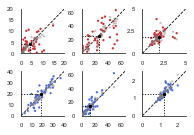

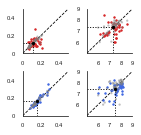

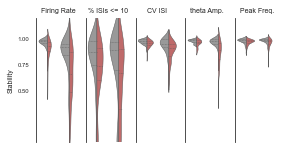

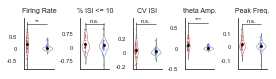

In [5]:
# Fig 5b: supra-threshold longitudinal scatter grid
f5b = SHEETS['5b']
def vals_5b(strain, col):
    return f5b.loc[f5b['Strain'] == strain, col].dropna().to_numpy()

SVG_PARAMS_5B = {'figsize_mm': (75, 50), 'fontsize_ticks': 6, 'scatter_size': 5, 'mean_marker_size': 5, 'diag_line_width': 0.8, 'mean_line_width': 1, 'space_between': 0.4, 'alpha_ctrl': 0.5, 'alpha_longi': 1.0}

def _set_ticks(ax, ticks, fontsize):
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels([f'{t:g}' for t in ticks], fontsize=fontsize)
    ax.set_yticklabels([f'{t:g}' for t in ticks], fontsize=fontsize)

def plot_supra_scatters_svg(params, setups):
    fig, axs = plt.subplots(2, 3, figsize=mm_to_inches(params['figsize_mm']))
    for s in setups:
        ax = axs[s['row'], s['col']]
        xL = np.asarray(s['x_longi']); yL = np.asarray(s['y_longi'])
        xC = np.asarray(s['x_ctrl']); yC = np.asarray(s['y_ctrl'])
        ax.scatter(xC, yC, color='gray', alpha=params['alpha_ctrl'], s=params['scatter_size'], edgecolors='none', zorder=3)
        ax.scatter(xL, yL, color=s['color'], alpha=params['alpha_longi'], s=params['scatter_size'], edgecolors='none', zorder=2)
        lo, hi = s['lims']
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=params['diag_line_width'], zorder=1)
        xm, ym = np.nanmean(xL), np.nanmean(yL)
        ax.plot([lo, xm], [ym, ym], 'k:', linewidth=params['mean_line_width'])
        ax.plot([xm, xm], [lo, ym], 'k:', linewidth=params['mean_line_width'])
        ax.scatter([xm], [ym], color='k', s=params['mean_marker_size'], zorder=4)
        _set_ticks(ax, s['ticks'], params['fontsize_ticks'])
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        strip_top_right(ax)
    plt.subplots_adjust(wspace=params['space_between'], hspace=params['space_between'])
    plt.show()

setups_5b = [
    dict(row=0, col=0, x_longi=vals_5b('CKII', 'Reg1_FR'), y_longi=vals_5b('CKII', 'Fam_FR'), x_ctrl=vals_5b('CKII', 'Reg1_FR'), y_ctrl=vals_5b('CKII', 'Reg2_FR'), color=PYR_COLOR, lims=(0, 20), ticks=[0, 5, 10, 15, 20]),
    dict(row=0, col=1, x_longi=vals_5b('CKII', 'Reg1_ISI<10') * 100, y_longi=vals_5b('CKII', 'Fam_ISI<10') * 100, x_ctrl=vals_5b('CKII', 'Reg1_ISI<10') * 100, y_ctrl=vals_5b('CKII', 'Reg2_ISI<10') * 100, color=PYR_COLOR, lims=(0, 65), ticks=[0, 20, 40, 60]),
    dict(row=0, col=2, x_longi=vals_5b('CKII', 'Reg1_CV_ISI'), y_longi=vals_5b('CKII', 'Fam_CV_ISI'), x_ctrl=vals_5b('CKII', 'Reg1_CV_ISI'), y_ctrl=vals_5b('CKII', 'Reg2_CV_ISI'), color=PYR_COLOR, lims=(0, 5), ticks=[0, 2.5, 5]),
    dict(row=1, col=0, x_longi=vals_5b('SST', 'Reg1_FR'), y_longi=vals_5b('SST', 'Fam_FR'), x_ctrl=vals_5b('SST', 'Reg1_FR'), y_ctrl=vals_5b('SST', 'Reg2_FR'), color=IN_COLOR, lims=(0, 40), ticks=[0, 10, 20, 30, 40]),
    dict(row=1, col=1, x_longi=vals_5b('SST', 'Reg1_ISI<10') * 100, y_longi=vals_5b('SST', 'Fam_ISI<10') * 100, x_ctrl=vals_5b('SST', 'Reg1_ISI<10') * 100, y_ctrl=vals_5b('SST', 'Reg2_ISI<10') * 100, color=IN_COLOR, lims=(0, 65), ticks=[0, 20, 40, 60]),
    dict(row=1, col=2, x_longi=vals_5b('SST', 'Reg1_CV_ISI'), y_longi=vals_5b('SST', 'Fam_CV_ISI'), x_ctrl=vals_5b('SST', 'Reg1_CV_ISI'), y_ctrl=vals_5b('SST', 'Reg2_CV_ISI'), color=IN_COLOR, lims=(0, 2.5), ticks=[0, 1, 2]),
]
plot_supra_scatters_svg(SVG_PARAMS_5B, setups_5b)

# Fig 5d: subthreshold theta power/frequency scatter grid
f5d = SHEETS['5d']
def vals_5d(strain, col):
    return f5d.loc[f5d['Strain'] == strain, col].dropna().to_numpy()

theta_power_ticks = [0, 0.2, 0.4]; max_freq_ticks = [6, 7, 8, 9]
SVG_PARAMS_5D = {'figsize_mm_sub': (50, 50), 'fontsize_ticks': 6, 'scatter_size': 2, 'mean_marker_size': 5, 'diag_line_width': 0.8, 'mean_line_width': 1, 'space_between': 0.4}

def create_subthreshold_scatters_combined(params, longi_setups, control_setups):
    fig, axs = plt.subplots(2, 2, figsize=mm_to_inches(params['figsize_mm_sub']))
    for (row, col, x_longi, y_longi, color, x_range, y_range, x_ticks, y_ticks, labels), (_, _, x_ctrl, y_ctrl, _, _, _, _, _, _) in zip(longi_setups, control_setups):
        ax = axs[row, col]
        ax.scatter(x_ctrl, y_ctrl, color='gray', alpha=0.5, marker='o', s=params['scatter_size'] + 3, zorder=3, edgecolors='none')
        ax.scatter(x_longi, y_longi, color=color, marker='o', s=params['scatter_size'], zorder=2, alpha=1)
        ax.plot(x_range, y_range, color='k', linestyle='--', linewidth=params['diag_line_width'], zorder=1)
        x_mean, y_mean = np.mean(x_longi), np.mean(y_longi)
        ax.plot([x_range[0], x_mean], [y_mean, y_mean], color='k', linestyle=':', linewidth=params['mean_line_width'])
        ax.plot([x_mean, x_mean], [y_range[0], y_mean], color='k', linestyle=':', linewidth=params['mean_line_width'])
        ax.scatter(x_mean, y_mean, color='k', s=params['mean_marker_size'], marker='o', zorder=4)
        ax.set_xticks(x_ticks); ax.set_xticklabels(labels, fontsize=params['fontsize_ticks'])
        ax.set_yticks(y_ticks); ax.set_yticklabels(labels, fontsize=params['fontsize_ticks'])
        ax.set_xlim(x_range); ax.set_ylim(y_range)
        strip_top_right(ax)
    axs[1, 1].set_ylim(5, 9); axs[1, 1].set_xlim(5, 9)
    axs[0, 1].set_ylim(5, 9); axs[0, 1].set_xlim(5, 9)
    plt.subplots_adjust(wspace=params['space_between'], hspace=params['space_between'])
    plt.show()

control_setups = [
    (0, 0, vals_5d('CKII', 'W0_first_half_Theta_Power'), vals_5d('CKII', 'W0_second_half_Theta_Power'), PYR_COLOR, [0, 0.5], [0, 0.5], theta_power_ticks, theta_power_ticks, ['0', '0.2', '0.4']),
    (0, 1, vals_5d('CKII', 'W0_first_half_Max_Freq'), vals_5d('CKII', 'W0_second_half_Max_Freq'), PYR_COLOR, [5, 10], [5, 10], max_freq_ticks, max_freq_ticks, ['6', '7', '8', '9']),
    (1, 0, vals_5d('SST', 'W0_first_half_Theta_Power'), vals_5d('SST', 'W0_second_half_Theta_Power'), IN_COLOR, [0, 0.5], [0, 0.5], theta_power_ticks, theta_power_ticks, ['0', '0.2', '0.4']),
    (1, 1, vals_5d('SST', 'W0_first_half_Max_Freq'), vals_5d('SST', 'W0_second_half_Max_Freq'), IN_COLOR, [5, 10], [5, 10], max_freq_ticks, max_freq_ticks, ['6', '7', '8', '9']),
]
longi_setups = [
    (0, 0, vals_5d('CKII', 'W0_first_half_Theta_Power'), vals_5d('CKII', 'W2_first_half_Theta_Power'), PYR_COLOR, [0, 0.5], [0, 0.5], theta_power_ticks, theta_power_ticks, ['0', '0.2', '0.4']),
    (0, 1, vals_5d('CKII', 'W0_first_half_Max_Freq'), vals_5d('CKII', 'W2_first_half_Max_Freq'), PYR_COLOR, [5, 10], [5, 10], max_freq_ticks, max_freq_ticks, ['6', '7', '8', '9']),
    (1, 0, vals_5d('SST', 'W0_first_half_Theta_Power'), vals_5d('SST', 'W2_first_half_Theta_Power'), IN_COLOR, [0, 0.5], [0, 0.5], theta_power_ticks, theta_power_ticks, ['0', '0.2', '0.4']),
    (1, 1, vals_5d('SST', 'W0_first_half_Max_Freq'), vals_5d('SST', 'W2_first_half_Max_Freq'), IN_COLOR, [5, 10], [5, 10], max_freq_ticks, max_freq_ticks, ['6', '7', '8', '9']),
]
create_subthreshold_scatters_combined(SVG_PARAMS_5D, longi_setups, control_setups)

# Fig 5e/5f: 
# 5e: within/between stability measures
f5e = SHEETS['5e'].rename(columns={'Strain': 'strain'}).copy()
measures = ['FR', 'BI', 'CV_ISI', 'theta_power', 'theta_freq']
labels = ['Firing Rate', '% ISIs <= 10', 'CV ISI', 'theta Amp.', 'Peak Freq.']
fig, axes = plt.subplots(1, 5, figsize=mm_to_inches((100, 52)), sharey=True)
for ax, metric, label in zip(axes, measures, labels):
    long_df = f5e[['strain', f'S_within_{metric}', f'S_between_{metric}']].melt(id_vars='strain', var_name='type', value_name='value')
    long_df['type'] = long_df['type'].str.contains('within').map({True: 'w', False: 'a'})
    sns.violinplot(data=long_df, x='strain', y='value', hue='type', split=True, inner='quartile', linewidth=0.5, width=0.8, palette={'w': '0.6', 'a': 'indianred'}, ax=ax)
    if ax.get_legend(): ax.get_legend().remove()
    ax.set_ylim(0, 1.2); ax.set_yticks([0.5, 0.75, 1.0]); ax.tick_params(axis='y', labelsize=SVG_TICKS)
    ax.set_xticks([]); ax.set_xlabel(''); ax.set_ylabel(''); ax.set_title(label, fontsize=SVG_LABELS)
    strip_top_right(ax); ax.spines['bottom'].set_visible(False)
axes[0].set_ylabel('Stability', fontsize=SVG_LABELS)
plt.tight_layout(pad=0.6); plt.show()

# 5f: S-delta distributions
f5f = SHEETS['5f'].rename(columns={'Strain': 'strain'}).copy()
configs = [('FR', ['**'], [-0.5, 0, 0.5], 'Firing Rate'), ('BI', ['n.s.'], [-0.75, 0, 0.75], '% ISI <= 10'), ('CV_ISI', ['n.s.'], [-0.2, 0, 0.2], 'CV ISI'), ('theta_power', ['***'], [-0.5, 0, 0.5], 'theta Amp.'), ('theta_freq', ['n.s.'], [-0.1, 0, 0.1], 'Peak Freq.')]
fig, axes = plt.subplots(1, 5, figsize=((12.5 * 5 * 1.5) / 25.4, 25 / 25.4), constrained_layout=True)
for ax, (metric, sig, yticks, title) in zip(axes, configs):
    col = f'S_delta_{metric}'
    data = [f5f.loc[f5f['strain'] == 'CKII', col].dropna().to_numpy(), f5f.loc[f5f['strain'] == 'SST', col].dropna().to_numpy()]
    sns.violinplot(data=data, color='white', linewidth=0.5, width=0.5, zorder=0, alpha=1, inner=None, ax=ax)
    for collection in ax.collections: collection.set_edgecolor('gray')
    for i, (vals, color) in enumerate(zip(data, [PYR_COLOR, IN_COLOR])):
        ax.scatter(np.random.normal(i, 0.02, len(vals)), vals, color=color, s=2, alpha=0.5, edgecolors='none')
        ax.scatter(i, np.nanmean(vals), color='k', s=3, zorder=2)
    all_vals = np.concatenate(data); pad = 0.1 * (np.nanmax(all_vals) - np.nanmin(all_vals) + 1e-12)
    ylim = (np.nanmin(all_vals) - pad, np.nanmax(all_vals) + pad * 3); ax.set_ylim(ylim)
    ax.set_yticks(yticks); ax.set_yticklabels([str(v) for v in yticks], fontsize=SVG_TICKS); ax.set_xticks([]); ax.set_title(title, fontsize=SVG_LABELS)
    y = max(np.nanmax(data[0]), np.nanmax(data[1])) + (ylim[1] - ylim[0]) * 0.1
    ax.plot([0, 0, 1, 1], [y, y, y, y], lw=0.5, c='k'); ax.text(0.5, y + (ylim[1] - ylim[0]) * 0.01, sig[0], ha='center', va='bottom', fontsize=SVG_TICKS)
    strip_top_right(ax)
fig.patch.set_facecolor('none'); plt.show()

## Fig6

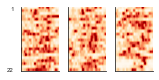

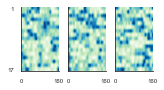

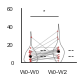

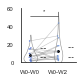

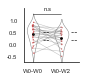

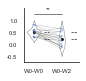

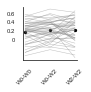

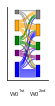

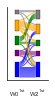

In [6]:
# 6b: heatmaps
vec_cols = ['FR_vec_W0_first_half', 'FR_vec_W0_second_half', 'FR_vec_W2_first_half']
for strain, cmap in [('CKII', 'OrRd'), ('SST', 'GnBu')]:
    df = SHEETS['6b'][SHEETS['6b']['Strain'] == strain]
    mats = [stack_vectors(df[c]) for c in vec_cols]
    if any(m.size == 0 for m in mats):
        continue
    fig, ax = plt.subplots(1, 3, figsize=(60/25.4, 30/25.4))
    for i, m in enumerate(mats):
        m = (m - np.min(m, axis=1, keepdims=True)) / (np.max(m, axis=1, keepdims=True) - np.min(m, axis=1, keepdims=True) + 1e-10)
        ax[i].imshow(m, aspect='auto', cmap=cmap)
        ax[i].set_yticks([0, len(m)-1], [1, len(m)], fontsize=SVG_TICKS)
        if strain == 'SST':
            ax[i].set_xticks([0, m.shape[1]-1], [0, 160], fontsize=SVG_TICKS)
        else:
            ax[i].set_xticks([])
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        if i > 0:
            ax[i].set_yticks([])
    plt.subplots_adjust(wspace=0.25)
    plt.show()

# 6c / 6d: violin + null envelopes 

def plot_paired_with_null(excel_path, value_a, value_b, yticks, ylims):
    obs = pd.read_excel(excel_path, sheet_name='observed')
    shf = pd.read_excel(excel_path, sheet_name='shuffled')
    for strain, palette in [('CKII', [PYR_COLOR, PYR_COLOR_weak]), ('SST', [IN_COLOR, IN_COLOR_weak])]:
        d = obs[obs['Strain'] == strain]
        a = d[value_a].dropna().to_numpy()
        b = d[value_b].dropna().to_numpy()
        fig, ax = plt.subplots(figsize=(25/25.4, 25/25.4))
        sns.violinplot(data=[a, b], color='white', linewidth=0.5, width=0.5, inner=None, ax=ax)
        for col in ax.collections:
            col.set_edgecolor('gray')
        for ln in ax.lines:
            ln.set_color('black'); ln.set_linewidth(0.5)
        j0 = np.random.normal(0, 0.02, len(a)); j1 = np.random.normal(0, 0.02, len(b))
        ax.scatter(0 + j0, a, color=palette[0], s=2, alpha=0.8, edgecolors='none')
        ax.scatter(1 + j1, b, color=palette[1], s=2, alpha=0.8, edgecolors='none')
        for i in range(min(len(a), len(b))):
            ax.plot([0+j0[i], 1+j1[i]], [a[i], b[i]], color='gray', alpha=0.5, linewidth=0.5)
        ax.scatter(0, np.mean(a), color='k', s=3)
        ax.scatter(1, np.mean(b), color='k', s=3)

        s = shf[shf['Strain'] == strain]
        for i, col_name in enumerate(['Shuffled_Mean_A', 'Shuffled_Mean_B']):
            lo, hi = np.percentile(s[col_name], [1, 99])
            ax.plot([i+0.35, i+0.55], [lo, lo], color='k', linestyle='--', linewidth=0.6)
            ax.plot([i+0.35, i+0.55], [hi, hi], color='k', linestyle='--', linewidth=0.6)

        p = stats.wilcoxon(a, b).pvalue if len(a) == len(b) else stats.ranksums(a, b).pvalue
        sig = 'n.s' if p > 0.05 else ('***' if p < 0.001 else ('**' if p < 0.01 else '*'))
        ax.plot([0,1], [ylims[1]*0.85, ylims[1]*0.85], color='k', linewidth=0.5)
        ax.text(0.5, ylims[1]*0.9, sig, ha='center', va='bottom', fontsize=SVG_TICKS)

        ax.set_xticks([0,1], ['W0-W0', 'W0-W2'], fontsize=SVG_TICKS)
        ax.set_yticks(yticks, yticks, fontsize=SVG_TICKS)
        ax.set_ylim(*ylims)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        fig.patch.set_facecolor('none')
        plt.show()

plot_paired_with_null(SOURCE_DATA_DIR + r'\6c_new.xlsx', 'W0_W0_COM_Dist', 'W0_W2_COM_Dist', yticks=np.arange(0,61,20), ylims=(0,60))
plot_paired_with_null(SOURCE_DATA_DIR + r'\6d_new.xlsx', 'W0_W0_Corr', 'W0_W2_Corr', yticks=np.arange(-0.5,1.1,0.5), ylims=(-0.7,1.5))

# 6e
f6e = SHEETS['6e']
for strain, color in [('CKII', PYR_COLOR), ('SST', IN_COLOR)]:
    d = f6e[f6e['Strain'] == strain]
    if d.empty:
        continue
    vals = d[['W0_First_Half_Inst_Speed_R', 'W0_Second_Half_Inst_Speed_R', 'W2_First_Half_Inst_Speed_R']].to_numpy(float)
    fig, ax = plt.subplots(figsize=(25/25.4, 25/25.4))
    for row in vals:
        ax.plot([0,1,2], row, color='gray', alpha=0.5, linewidth=0.5)
    ax.scatter([0,1,2], np.nanmean(vals, axis=0), color='k', s=5)
    ax.set_xticks([0,1,2], ['W0-W0', 'W0-W2', 'W2-W2'], rotation=45, fontsize=SVG_TICKS)
    ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6], fontsize=SVG_TICKS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')
    plt.show()

# strict sankey recreation for 6f
from matplotlib.path import Path
from matplotlib.patches import PathPatch

def create_bezier_curve(x1, y1, x2, y2, curvature=0.4):
    verts = [(x1, y1), (x1 + curvature, y1), (x2 - curvature, y2), (x2, y2)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    return Path(verts, codes)

def calculate_positions(counts, categories, spacing):
    return np.cumsum([counts.get(cat,0) + spacing for cat in categories]) - np.array([(counts.get(cat,0)+spacing)/2 for cat in categories])

def compute_ordered_y_positions(counts, positions, categories):
    return {cat: [positions[i] - counts.get(cat,0)/2 + j + 0.5 for j in range(counts.get(cat,0))] for i, cat in enumerate(categories)}

def plot_sankey_svg_style(fam_counts, nov_counts, transitions, strain='SST', figsize_mm=(22,40), svg_label_size=6, spacing=5, xticklabels=('Fam 1','Fam 2')):
    categories = ['speed','both','space','uniform','non-tuned']
    colors = {'speed':'blue','space':'green','both':'purple','uniform':'orange','non-tuned':'gray','tuned':'green'}

    fam_pos = calculate_positions(fam_counts, categories, spacing)
    nov_pos = calculate_positions(nov_counts, categories, spacing)

    sorted_transitions = {cat: [] for cat in categories}
    for f,n in transitions:
        if f in sorted_transitions:
            sorted_transitions[f].append((f,n))
    for cat in categories:
        sorted_transitions[cat].sort(key=lambda x: categories.index(x[1]) if x[1] in categories else 999)

    fig, ax = plt.subplots(figsize=(figsize_mm[0]/25.4, figsize_mm[1]/25.4))
    x_fam, x_nov = 0, 1
    for i, cat in enumerate(categories):
        ax.bar(x_fam, fam_counts.get(cat,0), bottom=fam_pos[i]-fam_counts.get(cat,0)/2, width=0.2, color=colors[cat], edgecolor='black', linewidth=0.3)
        ax.bar(x_nov, nov_counts.get(cat,0), bottom=nov_pos[i]-nov_counts.get(cat,0)/2, width=0.2, color=colors[cat], edgecolor='black', linewidth=0.3)

    fam_y = compute_ordered_y_positions(fam_counts, fam_pos, categories)
    nov_y = compute_ordered_y_positions(nov_counts, nov_pos, categories)

    for fam_cat in categories:
        for _, nov_cat in sorted_transitions[fam_cat]:
            if nov_cat not in nov_y:
                continue
            if fam_y[fam_cat] and nov_y[nov_cat]:
                y1 = fam_y[fam_cat].pop(0)
                y2 = nov_y[nov_cat].pop(0)
                path = create_bezier_curve(x_fam + 0.1, y1, x_nov - 0.1, y2)
                patch = PathPatch(path, facecolor='none', edgecolor=colors[fam_cat], alpha=0.7, lw=1)
                ax.add_patch(patch)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, max(fam_pos[-1], nov_pos[-1]) + spacing)
    ax.set_xticks([x_fam, x_nov])
    ax.set_xticklabels(xticklabels, fontsize=svg_label_size)
    ax.set_yticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    plt.show()

f6f = SHEETS['6f']
d = f6f[f6f['Strain'] == 'SST'].copy()
if not d.empty:
    # W0 first -> W0 second
    W0_1_counts = d['W0_1_Class'].value_counts().to_dict()
    W0_2_counts = d['W0_2_Class'].value_counts().to_dict()
    trans_12 = list(zip(d['W0_1_Class'], d['W0_2_Class']))
    plot_sankey_svg_style(W0_1_counts, W0_2_counts, trans_12, strain='SST', figsize_mm=(22,40), svg_label_size=6,
                          xticklabels=(r'$\mathregular{W0^{1st}}$', r'$\mathregular{W0^{2nd}}$'))

    # W0 first -> W2 first
    W2_counts = d['W2_Class'].value_counts().to_dict()
    trans_13 = list(zip(d['W0_1_Class'], d['W2_Class']))
    plot_sankey_svg_style(W0_1_counts, W2_counts, trans_13, strain='SST', figsize_mm=(22,40), svg_label_size=6,
                          xticklabels=(r'$\mathregular{W0^{1st}}$', r'$\mathregular{W2^{1st}}$'))


## Fig7

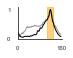

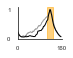

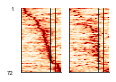

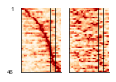

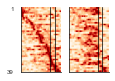

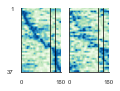

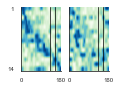

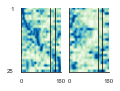

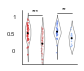

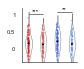

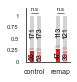

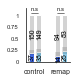

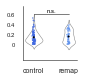

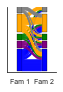

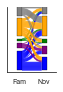

In [2]:
# Fig 7b: lick traces 
RZ = [53, 64]
f7b = SHEETS['7b']
for j in [1, 5]:
    plt.figure(figsize=mm_to_inches((20, 15)))
    df = f7b[f7b['trial'] == j]
    plt.plot(df['position_bin'], df['novel_norm_lick'], '-', color='0.6', linewidth=1, label='Novel')
    plt.plot(df['position_bin'], df['familiar_norm_lick'], '-', color='k', linewidth=1, label='Familiar')
    plt.xlim(0, 80); plt.ylim(0, 1.1)
    plt.xticks(np.linspace(0, 80, 2), np.linspace(0, 160, 2).astype(int), fontsize=6)
    plt.yticks(np.linspace(0, 1, 2), np.linspace(0, 1, 2).astype(int), fontsize=6)
    plt.axvspan(RZ[0], RZ[1], alpha=0.5, color='orange')
    ax = plt.gca(); strip_top_right(ax); ax.set_facecolor('none')
    plt.tick_params(axis='both', which='major', labelsize=6)
    plt.show()

# Fig 7d: heatmap format restored from individual 
f7d = SHEETS['7d']

def plot_7d_pair(first_mat, second_mat, strain, cmap):
    first = normalize_rows(first_mat); second = normalize_rows(second_mat)
    first[np.isnan(first)] = 0; second[np.isnan(second)] = 0
    sorted_first, idx = sort_rows_by_max_index(first)
    sorted_second = second[idx] if len(idx) else second
    fig, ax = plt.subplots(1, 2, figsize=mm_to_inches((40, 30)))
    ax[0].imshow(sorted_first, aspect='auto', cmap=cmap)
    ax[0].set_yticks([0, len(sorted_first) - 1], [1, len(sorted_first)], fontsize=SVG_TICKS)
    if strain == 'SST': ax[0].set_xticks([0, 47], [0, 160], fontsize=SVG_TICKS)
    else: ax[0].set_xticks([])
    strip_top_right(ax[0]); ax[0].axvline(x=35, color='k', alpha=0.7, linewidth=1); ax[0].axvline(x=40, color='k', alpha=0.7, linewidth=1)
    ax[1].imshow(sorted_second, aspect='auto', cmap=cmap)
    ax[1].set_yticks([])
    if strain == 'SST': ax[1].set_xticks([0, 47], [0, 160], fontsize=SVG_TICKS)
    else: ax[1].set_xticks([])
    strip_top_right(ax[1]); ax[1].axvline(x=35, color='k', alpha=0.7, linewidth=1); ax[1].axvline(x=40, color='k', alpha=0.7, linewidth=1)
    fig.patch.set_alpha(0)
    plt.subplots_adjust(wspace=0.2)
    plt.show()

for strain, cmap in [('CKII', 'OrRd'), ('SST', 'GnBu')]:
    control = f7d[(f7d['Strain'] == strain) & (f7d['Condition'] == 'Control_Fam1_tuned')]
    remap_fam = f7d[(f7d['Strain'] == strain) & (f7d['Condition'] == 'Remap_Fam_tuned')]
    remap_nov = f7d[(f7d['Strain'] == strain) & (f7d['Condition'] == 'Remap_Nov_tuned')]
    if not control.empty:
        plot_7d_pair(stack_vectors(control['First_Half_FR_Vec'], 48), stack_vectors(control['Second_Half_FR_Vec'], 48), strain, cmap)
    if not remap_fam.empty:
        plot_7d_pair(stack_vectors(remap_fam['First_Half_FR_Vec'], 48), stack_vectors(remap_fam['Second_Half_FR_Vec'], 48), strain, cmap)
    if not remap_nov.empty:
        plot_7d_pair(stack_vectors(remap_nov['First_Half_FR_Vec'], 48), stack_vectors(remap_nov['Second_Half_FR_Vec'], 48), strain, cmap)

# Fig 7e: tuned and untuned correlation violins in  four-group style
for sheet in ['7e_tuned', '7e_untuned']:
    d = SHEETS[sheet]
    data = {
        'CKII regs': d[(d['Strain'] == 'CKII') & (d['Condition'].str.lower() == 'control')]['Corr'].dropna().to_numpy(),
        'CKII fam-nov': d[(d['Strain'] == 'CKII') & (d['Condition'].str.lower() == 'remap')]['Corr'].dropna().to_numpy(),
        'SST regs': d[(d['Strain'] == 'SST') & (d['Condition'].str.lower() == 'control')]['Corr'].dropna().to_numpy(),
        'SST fam-nov': d[(d['Strain'] == 'SST') & (d['Condition'].str.lower() == 'remap')]['Corr'].dropna().to_numpy(),
    }
    paper_violin(data, [PYR_COLOR, PYR_COLOR_weak, IN_COLOR, IN_COLOR_weak], figsize_mm=(25, 25), ylim=[-0.4, 1.2],
                 jitter=0.03, scatter_size=2, alpha=0.5, yticks=[0, 0.5, 1],
                 significance_pairs=[(0, 1), (2, 3)], significance_labels=['***', '**'])

# Fig 7f: PC proportion bars with Wilson CI
f7f = SHEETS['7f']
for strain in ['CKII', 'SST']:
    fig, ax = plt.subplots(figsize=mm_to_inches((20, 25)))
    barWidth = 0.25; within_gap = 0.08; group_gap = 1.2
    x = np.array([0, barWidth + within_gap, group_gap, group_gap + barWidth + within_gap])
    d_reg = f7f[(f7f['Strain'] == strain) & (f7f['Condition'].str.lower() == 'control')]
    d_remap = f7f[(f7f['Strain'] == strain) & (f7f['Condition'].str.lower() == 'remap')]
    pc_counts = np.array([d_reg['is_PC_first_half'].sum(), d_reg['is_PC_second_half'].sum(), d_remap['is_PC_first_half'].sum(), d_remap['is_PC_second_half'].sum()], dtype=float)
    total_counts = np.array([len(d_reg), len(d_reg), len(d_remap), len(d_remap)], dtype=float)
    non_pc_counts = total_counts - pc_counts
    pc_props = pc_counts / total_counts; non_pc_props = 1 - pc_props
    half_colors = [PYR_COLOR, '#ff9aa2', PYR_COLOR, '#ff9aa2'] if strain == 'CKII' else [IN_COLOR, '#8ecae6', IN_COLOR, '#8ecae6']
    for i in range(len(x)):
        plt.bar(x[i], pc_props[i], width=barWidth, color=half_colors[i], zorder=2)
        plt.bar(x[i], non_pc_props[i], width=barWidth, bottom=pc_props[i], color='lightgray', zorder=1)
    ci_lows, ci_highs = [], []
    for count_i, total_i in zip(pc_counts, total_counts):
        ci_low, ci_high = proportion_confint(count=int(count_i), nobs=int(total_i), alpha=0.05, method='wilson')
        ci_lows.append(ci_low); ci_highs.append(ci_high)
    for i in range(len(x)):
        plt.fill_between([x[i] - barWidth / 2, x[i] + barWidth / 2], [ci_lows[i], ci_lows[i]], [ci_highs[i], ci_highs[i]], color='k', alpha=0.12, linewidth=0, zorder=3)
        plt.text(x[i] + 0.04, pc_props[i] / 2, f'{int(pc_counts[i])}', ha='center', va='center', rotation=90, color='k', fontsize=SVG_LABELS)
        plt.text(x[i] + 0.04, pc_props[i] + non_pc_props[i] / 2, f'{int(non_pc_counts[i])}', ha='center', va='center', rotation=90, color='k', fontsize=SVG_LABELS)
    control_center = np.mean(x[:2]); remap_center = np.mean(x[2:])
    plt.xticks([control_center, remap_center], ['control', 'remap'], fontsize=SVG_LABELS)
    plt.yticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize=SVG_TICKS)
    strip_top_right(ax); ax.set_ylim(0, 1.15)
    ylim = ax.get_ylim(); y = ylim[1] * 0.92; text_y = ylim[1] * 0.95
    plt.plot([x[0], x[1]], [y, y], color='black', linewidth=0.5); plt.plot([x[2], x[3]], [y, y], color='black', linewidth=0.5)
    plt.text(control_center, text_y, 'n.s', fontsize=SVG_TICKS, ha='center'); plt.text(remap_center, text_y, 'n.s', fontsize=SVG_TICKS, ha='center')
    ax.set_xlim(-0.25, group_gap + barWidth + within_gap + 0.25)
    plt.show()

# Fig 7g: 
f7g = SHEETS['7g']
d = f7g[f7g['Strain'] == 'SST']
data_7g = {'control': d[d['Condition'].str.lower() == 'control']['r_val_difference'].dropna().to_numpy(), 'remap': d[d['Condition'].str.lower() == 'remap']['r_val_difference'].dropna().to_numpy()}
paper_violin(data_7g, [IN_COLOR, IN_COLOR_weak], figsize_mm=(25, 25), yticks=[0, 0.2, 0.4, 0.6], ylim=(-0.3, 0.75),
             alpha=0.8, significance_pairs=[(0, 1)], xticklabels=['control', 'remap'])

# Fig 7h: Sankey transitions, original SVG-style bars/curves
from matplotlib.path import Path
from matplotlib.patches import PathPatch

def create_bezier_curve(x1, y1, x2, y2, curvature=0.4):
    verts = [(x1, y1), (x1 + curvature, y1), (x2 - curvature, y2), (x2, y2)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    return Path(verts, codes)

def plot_sankey_svg_style(fam_counts, nov_counts, transitions, strain='SST', figsize_mm=(25, 35), svg_label_size=SVG_LABELS, spacing=5, xticklabels=('Fam 1', 'Fam 2')):
    categories = ['speed', 'both', 'space', 'uniform', 'non-tuned'] if strain != 'CKII' else ['tuned', 'non-tuned']
    colors = {'speed': 'blue', 'space': 'green', 'both': 'purple', 'uniform': 'orange', 'non-tuned': 'gray', 'tuned': 'green'}
    fam_counts = {cat: int(fam_counts.get(cat, 0)) for cat in categories}; nov_counts = {cat: int(nov_counts.get(cat, 0)) for cat in categories}
    fam_pos = np.cumsum([fam_counts[cat] + spacing for cat in categories]) - np.array([(fam_counts[cat] + spacing) / 2 for cat in categories])
    nov_pos = np.cumsum([nov_counts[cat] + spacing for cat in categories]) - np.array([(nov_counts[cat] + spacing) / 2 for cat in categories])
    sorted_transitions = {cat: [] for cat in categories}
    for f, n in transitions:
        if f in sorted_transitions and n in categories: sorted_transitions[f].append((f, n))
    for cat in categories: sorted_transitions[cat].sort(key=lambda x: categories.index(x[1]))
    fig, ax = plt.subplots(figsize=mm_to_inches(figsize_mm)); x_fam, x_nov = 0, 1
    for i, cat in enumerate(categories):
        ax.bar(x_fam, fam_counts[cat], bottom=fam_pos[i] - fam_counts[cat] / 2, width=0.2, color=colors[cat], edgecolor='black', linewidth=0.3)
        ax.bar(x_nov, nov_counts[cat], bottom=nov_pos[i] - nov_counts[cat] / 2, width=0.2, color=colors[cat], edgecolor='black', linewidth=0.3)
    fam_y = {cat: [fam_pos[i] - fam_counts[cat] / 2 + j + 0.5 for j in range(fam_counts[cat])] for i, cat in enumerate(categories)}
    nov_y = {cat: [nov_pos[i] - nov_counts[cat] / 2 + j + 0.5 for j in range(nov_counts[cat])] for i, cat in enumerate(categories)}
    for fam_cat in categories:
        for _, nov_cat in sorted_transitions[fam_cat]:
            if fam_y[fam_cat] and nov_y[nov_cat]:
                y1 = fam_y[fam_cat].pop(0); y2 = nov_y[nov_cat].pop(0)
                ax.add_patch(PathPatch(create_bezier_curve(x_fam + 0.1, y1, x_nov - 0.1, y2), facecolor='none', edgecolor=colors[fam_cat], alpha=0.7, lw=1))
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(0, max(fam_pos[-1], nov_pos[-1]) + spacing)
    ax.set_xticks([x_fam, x_nov]); ax.set_xticklabels(xticklabels, fontsize=svg_label_size); ax.set_yticks([])
    strip_top_right(ax); plt.tight_layout(); plt.show()

for sheet, left, right, ticks in [('7h_control', 'Fam 1 Class', 'Fam 2 Class', ('Fam 1', 'Fam 2')), ('7h_remap', 'Fam Class', 'Nov Class', ('Fam', 'Nov'))]:
    d = SHEETS[sheet]; d = d[d['Strain'] == 'SST']
    plot_sankey_svg_style(d[left].value_counts().to_dict(), d[right].value_counts().to_dict(), list(zip(d[left], d[right])), strain='SST', figsize_mm=(25, 35), svg_label_size=SVG_LABELS, xticklabels=ticks)

## Fig8

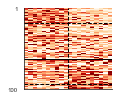

CKII-remap: n = 100
CKII-remap: 18.00% decreasing second half
CKII-remap: 6.00% increasing second half
CKII-remap: 37.00% higher second half


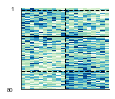

SST-remap: n = 80
SST-remap: 2.50% decreasing second half
SST-remap: 22.50% increasing second half
SST-remap: 66.25% higher second half


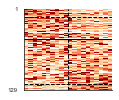

CKII-control: n = 129
CKII-control: 10.08% decreasing second half
CKII-control: 6.98% increasing second half
CKII-control: 48.06% higher second half


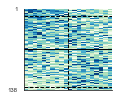

SST-control: n = 138
SST-control: 8.70% decreasing second half
SST-control: 4.35% increasing second half
SST-control: 50.72% higher second half


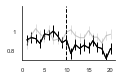

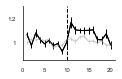

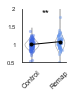

SST: remap n = 80, control n = 138
SST: ranksums = RanksumsResult(statistic=2.8204456454735793, pvalue=0.004795699721098442)


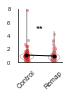

CKII: remap n = 100, control n = 129
CKII: ranksums = RanksumsResult(statistic=-2.5983303342307384, pvalue=0.009367832659054269)


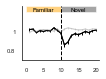

8f: remap n = 180, control n = 267


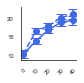

In [8]:
# Matrix-style recreation for Fig8
P_THRESHOLD = 0.05
laps_to_take = 10

f8 = SHEETS['8a-d'].copy()
if 'Condition' not in f8.columns:
    raise ValueError("Sheet '8a-d' must include a Condition column. Do not infer it by merging to 8e because Cell_ID + Strain is not unique.")
if f8.duplicated(['Cell_ID', 'Strain', 'Condition']).any():
    dup_count = int(f8.duplicated(['Cell_ID', 'Strain', 'Condition']).sum())
    print(f"Warning: 8a-d has {dup_count} duplicate Cell_ID + Strain + Condition rows.")

lap_pre = [f'FR_lap_{i}_pre' for i in range(1, 11)]
lap_post = [f'FR_lap_{i}_post' for i in range(1, 11)]

def condition_mask(df, condition):
    labels = df['Condition'].astype(str).str.lower()
    if condition == 'remap':
        return labels.str.contains('remap', na=False)
    if condition == 'control':
        return labels.eq('control')
    raise ValueError(condition)

def build_mat(df):
    fam = df[lap_pre].to_numpy(float)
    nov = df[lap_post].to_numpy(float)
    return fam, nov

def normalize_rows(mat):
    out = mat.copy().astype(float)
    for i in range(len(out)):
        row = out[i]
        mn = np.nanmin(row)
        mx = np.nanmax(row)
        if np.isnan(mn) or np.isnan(mx) or mx == mn:
            out[i] = np.where(np.isnan(row), np.nan, 0)
        else:
            out[i] = np.where(np.isnan(row), np.nan, (row - mn) / (mx - mn))
    return out[~np.isnan(out).all(axis=1)]

def plot_matrix_block(strain, fam_mat, nov_mat, cmap):
    if len(fam_mat) == 0 or len(nov_mat) == 0:
        return
    connected = np.concatenate((fam_mat, nov_mat), axis=1)
    connected = normalize_rows(connected)
    if connected.size == 0:
        return

    t_stats, p_vals = [], []
    for row in connected:
        fam = row[:laps_to_take]
        nov = row[laps_to_take:]
        mask = ~(np.isnan(fam) | np.isnan(nov))
        fam_v, nov_v = fam[mask], nov[mask]
        if len(fam_v) < 2:
            t, p = np.nan, np.nan
        else:
            t, p = stats.ttest_rel(fam_v, nov_v)
        t_stats.append(t)
        p_vals.append(p)
    t_stats = np.array(t_stats)
    p_vals = np.array(p_vals)

    idx = np.argsort(t_stats)[::-1]
    connected_sorted = connected[idx]
    t_sorted = t_stats[idx]
    p_sorted = p_vals[idx]

    sig_pos = np.where((t_sorted > 0) & (p_sorted < P_THRESHOLD))[0]
    sig_neg = np.where((t_sorted < 0) & (p_sorted < P_THRESHOLD))[0]
    top_line = sig_pos[-1] + 0.5 if len(sig_pos) else None
    bottom_line = sig_neg[0] - 0.5 if len(sig_neg) else None

    ratios = np.nanmean(connected_sorted[:, 10:], axis=1) / np.nanmean(connected_sorted[:, :10], axis=1)
    ratio_idx = np.where(ratios >= 1)[0]

    fig, ax = plt.subplots(figsize=(40/25.4, 38/25.4))
    ax.imshow(connected_sorted, aspect='auto', cmap=cmap, interpolation='none', vmin=0, vmax=1)
    ax.set_yticks([0, len(connected_sorted)-1], [1, len(connected_sorted)], fontsize=SVG_TICKS)
    ax.set_xticks([])
    ax.axvline(x=9.5, color='k', linestyle='--', linewidth=1)
    if top_line is not None:
        ax.axhline(y=top_line, color='k', linestyle='--', linewidth=1)
    if bottom_line is not None:
        ax.axhline(y=bottom_line, color='k', linestyle='--', linewidth=1)
    if len(ratio_idx):
        ax.axhline(y=ratio_idx[0] + 0.5, color='k', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')
    plt.show()

    print(f'{strain}: n = {len(connected)}')
    print(f'{strain}: {len(sig_pos) / len(connected) * 100:.2f}% decreasing second half')
    print(f'{strain}: {len(sig_neg) / len(connected) * 100:.2f}% increasing second half')
    print(f'{strain}: {np.sum(ratios >= 1) / len(connected) * 100:.2f}% higher second half')

# 8a/8c matrices and 8b/8d population lines:
for cond, label in [('remap', 'remap'), ('control', 'control')]:
    dcond = f8[condition_mask(f8, cond)]
    for strain, cmap in [('CKII', 'OrRd'), ('SST', 'GnBu')]:
        ds = dcond[dcond['Strain'] == strain]
        if ds.empty:
            continue
        fam, nov = build_mat(ds)
        plot_matrix_block(strain=f'{strain}-{label}', fam_mat=fam, nov_mat=nov, cmap=cmap)

# 8b/8d line panels, matching the original remap-vs-control per strain layout.
total_lap_range = laps_to_take * 2 + 1
for strain in ['CKII', 'SST']:
    ds = f8[f8['Strain'] == strain]
    remap_f, remap_n = build_mat(ds[condition_mask(ds, 'remap')])
    reg_f, reg_n = build_mat(ds[condition_mask(ds, 'control')])
    if len(remap_f) == 0 or len(reg_f) == 0:
        continue

    avg_fr = np.concatenate((np.nanmean(remap_f, axis=0), np.nanmean(remap_n, axis=0)))
    sem_fr = np.concatenate((stats.sem(remap_f, axis=0, nan_policy='omit'), stats.sem(remap_n, axis=0, nan_policy='omit')))
    avg_fr_control = np.concatenate((np.nanmean(reg_f, axis=0), np.nanmean(reg_n, axis=0)))
    sem_fr_control = np.concatenate((stats.sem(reg_f, axis=0, nan_policy='omit'), stats.sem(reg_n, axis=0, nan_policy='omit')))

    fig, ax = plt.subplots(figsize=(42/25.4, 25/25.4))
    ax.errorbar(np.arange(1, total_lap_range), avg_fr, yerr=sem_fr, color='k', linewidth=1)
    ax.plot(np.arange(1, total_lap_range), avg_fr, color='k', linewidth=1)
    ax.errorbar(np.arange(1, total_lap_range), avg_fr_control, yerr=sem_fr_control, color='0.6', linewidth=1, alpha=0.3)
    ax.plot(np.arange(1, total_lap_range), avg_fr_control, color='0.6', linewidth=1, alpha=0.3)
    if strain == 'CKII':
        ax.set_yticks([0.8, 1], [0.8, 1], fontsize=SVG_TICKS)
        ax.set_ylim(0.7, 1.25)
    else:
        ax.set_yticks([1, 1.2], [1, 1.2], fontsize=SVG_TICKS)
        ax.set_ylim(0.85, 1.3)
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.tick_params(axis='x', labelsize=SVG_TICKS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(10, color='k', linestyle='--', linewidth=1)
    fig.patch.set_facecolor('none')
    plt.show()

# 8e violin/scatter:
f8e = SHEETS['8e'].copy()
for strain, color, weak_color, ylim, yticks, sig_y in [
    ('SST', IN_COLOR, IN_COLOR_weak, (0.5, 2), [0.5, 1, 1.5, 2], 1.8),
    ('CKII', PYR_COLOR, PYR_COLOR_weak, (0, 5), [0, 2, 4, 6, 8], 4.5),
]:
    d = f8e[f8e['Strain'] == strain]
    if d.empty:
        continue
    control = d[condition_mask(d, 'control')]['FR_ratio'].dropna().to_numpy(float)
    remap = d[condition_mask(d, 'remap')]['FR_ratio'].dropna().to_numpy(float)
    fig, ax = plt.subplots(figsize=(20/25.4, 25/25.4))
    sns.violinplot(data=[control, remap], color='white', linewidth=0.5, width=0.5, zorder=0, alpha=1, inner=None, ax=ax)
    jitter_control = np.random.normal(0, 0.03, size=len(control))
    jitter_remap = np.random.normal(1, 0.03, size=len(remap))
    ax.scatter(jitter_control, control, color=color, zorder=1, alpha=0.4, linewidths=0, s=10)
    ax.scatter(jitter_remap, remap, color=weak_color, zorder=1, alpha=0.4, linewidths=0, s=10)
    ax.plot([0, 1], [np.mean(control), np.mean(remap)], color='k', linestyle='-', linewidth=1, marker='o', markersize=3, zorder=10)
    ax.set_ylim(*ylim)
    ax.set_xticks([0, 1], ['Control', 'Remap'], fontsize=SVG_LABELS, rotation=45)
    ax.set_yticks(yticks, yticks, fontsize=SVG_TICKS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.5, sig_y, '**', fontsize=10, color='k', ha='center')
    fig.patch.set_facecolor('none')
    plt.show()
    print(f'{strain}: remap n = {len(remap)}, control n = {len(control)}')
    print(f'{strain}: ranksums = {stats.ranksums(remap, control)}')

# 8f speed line panel, pooled across strains.
f8f = SHEETS['8f'].copy()
if 'Condition' not in f8f.columns:
    raise ValueError("Sheet '8f' must include a Condition column.")
sp_pre = [f'Speed_lap_{i}_pre' for i in range(1, 11)]
sp_post = [f'Speed_lap_{i}_post' for i in range(1, 11)]

remap_speed_f = f8f.loc[condition_mask(f8f, 'remap'), sp_pre].to_numpy(float)
remap_speed_n = f8f.loc[condition_mask(f8f, 'remap'), sp_post].to_numpy(float)
reg_speed_f = f8f.loc[condition_mask(f8f, 'control'), sp_pre].to_numpy(float)
reg_speed_n = f8f.loc[condition_mask(f8f, 'control'), sp_post].to_numpy(float)

avg_speed = np.concatenate((np.nanmean(remap_speed_f, axis=0), np.nanmean(remap_speed_n, axis=0)))
sem_speed = np.concatenate((stats.sem(remap_speed_f, axis=0, nan_policy='omit'), stats.sem(remap_speed_n, axis=0, nan_policy='omit')))
avg_speed_control = np.concatenate((np.nanmean(reg_speed_f, axis=0), np.nanmean(reg_speed_n, axis=0)))
sem_speed_control = np.concatenate((stats.sem(reg_speed_f, axis=0, nan_policy='omit'), stats.sem(reg_speed_n, axis=0, nan_policy='omit')))

fig, ax = plt.subplots(figsize=(35/25.4, 25/25.4))
ax.errorbar(np.arange(1, 21), avg_speed, yerr=sem_speed, color='k', linewidth=1)
ax.plot(np.arange(1, 21), avg_speed, color='k', linewidth=1)
ax.errorbar(np.arange(1, 21), avg_speed_control, yerr=sem_speed_control, color='0.6', linewidth=1, alpha=0.3)
ax.plot(np.arange(1, 21), avg_speed_control, color='0.6', linewidth=1, alpha=0.3)
ax.set_yticks([0.8, 1], [0.8, 1], fontsize=SVG_TICKS)
ax.set_ylim(0.7, 1.25)
ax.set_xticks([0, 5, 10, 15, 20])
ax.tick_params(axis='x', labelsize=SVG_TICKS)
ax.axvspan(0, 10, facecolor='orange', alpha=0.5, ymin=0.9, ymax=1)
ax.axvspan(10, 20, facecolor='0.3', alpha=0.5, ymin=0.9, ymax=1)
ylim_lower, ylim_upper = ax.get_ylim()
yrange = ylim_upper - ylim_lower
ax.text(5, ylim_upper - yrange * 0.06, 'Familiar', color='black', fontsize=SVG_TICKS, ha='center', va='center')
ax.text(15, ylim_upper - yrange * 0.06, 'Novel', color='black', fontsize=SVG_TICKS, ha='center', va='center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('none')
ax.axvline(10, color='k', linestyle='--', linewidth=1)
plt.show()
print(f'8f: remap n = {len(remap_speed_f)}, control n = {len(reg_speed_f)}')

# 8g: FR by speed bin (fam/nov)
for strain, color in [('CKII', PYR_COLOR), ('SST', IN_COLOR)]:
    d = SHEETS['8g'][SHEETS['8g']['Strain'] == strain]
    if d.empty:
        continue
    fam_cols = [c for c in d.columns if c.startswith('FR_fam_bin_')]
    nov_cols = [c for c in d.columns if c.startswith('FR_nov_bin_')]
    fam = d[fam_cols].to_numpy(float)
    nov = d[nov_cols].to_numpy(float)
    mean_f = np.nanmean(fam, axis=0)
    sem_f = stats.sem(fam, axis=0, nan_policy='omit')
    mean_n = np.nanmean(nov, axis=0)
    sem_n = stats.sem(nov, axis=0, nan_policy='omit')
    x = np.arange(len(mean_f))
    fig, ax = plt.subplots(figsize=(25/25.4, 25/25.4))
    ax.errorbar(x, mean_f, yerr=sem_f, fmt='o', color=color, linestyle='-', capsize=5)
    ax.errorbar(x, mean_n, yerr=sem_n, fmt='o', color=color, linestyle='--', capsize=5)
    ax.set_xticks(x, [str(i*10) for i in x], rotation=45, fontsize=SVG_TICKS)
    ax.tick_params(axis='y', labelsize=SVG_TICKS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')
    plt.show()
